# 分享预训练的模型 (PyTorch)

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [ ]:
!pip install datasets evaluate transformers[sentencepiece]
!apt install git-lfs

You will need to setup git, adapt your email and name in the following cell.

In [ ]:
!git config --global user.email "you@example.com"
!git config --global user.name "Your Name"

创建模型存储仓库的方法有以下三种：

*  使用 `push_to_hub API` 接口
*  使用 `huggingface_hub` Python 库
*  使用网页界面

创建仓库后，你可以通过 git 和 git-lfs 将文件上传到其中。


##使用 push_to_hub API

在进行下一步操作之前，**你需要生成一个身份验证令牌**，这样 huggingface_hub API 才会知道你是谁以及你对哪些空间具有写入权限。

如果你在 notebook 中，可以运行以下代码登录：

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

如果你已经尝试使用过 `Trainer` API 训练模型，将其**上传到 Hub 的最简单方法**是在定义 `TrainingArguments` 时设置 `push_to_hub=True`：

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    "bert-finetuned-mrpc", save_strategy="epoch", push_to_hub=True
)

这样，调用 `trainer.train()` 的时候， **Trainer 会在每次保存模型时（这里是每个训练周期）将其上传到 Hub 中你的账户下的一个仓库。** 该仓库的名称与你选择的输出目录名称相同（这里是 bert-finetuned-mrpc ），但你可以通过 `hub_model_id = "a_different_name"` 指定一个不同的名称。

最后，需要在训练循环结束后运行 trainer.push_to_hub() **上传模型的最新版本**。它还会生成一份包含所有相关元数据的模型卡片，包含使用的超参数和评估结果！

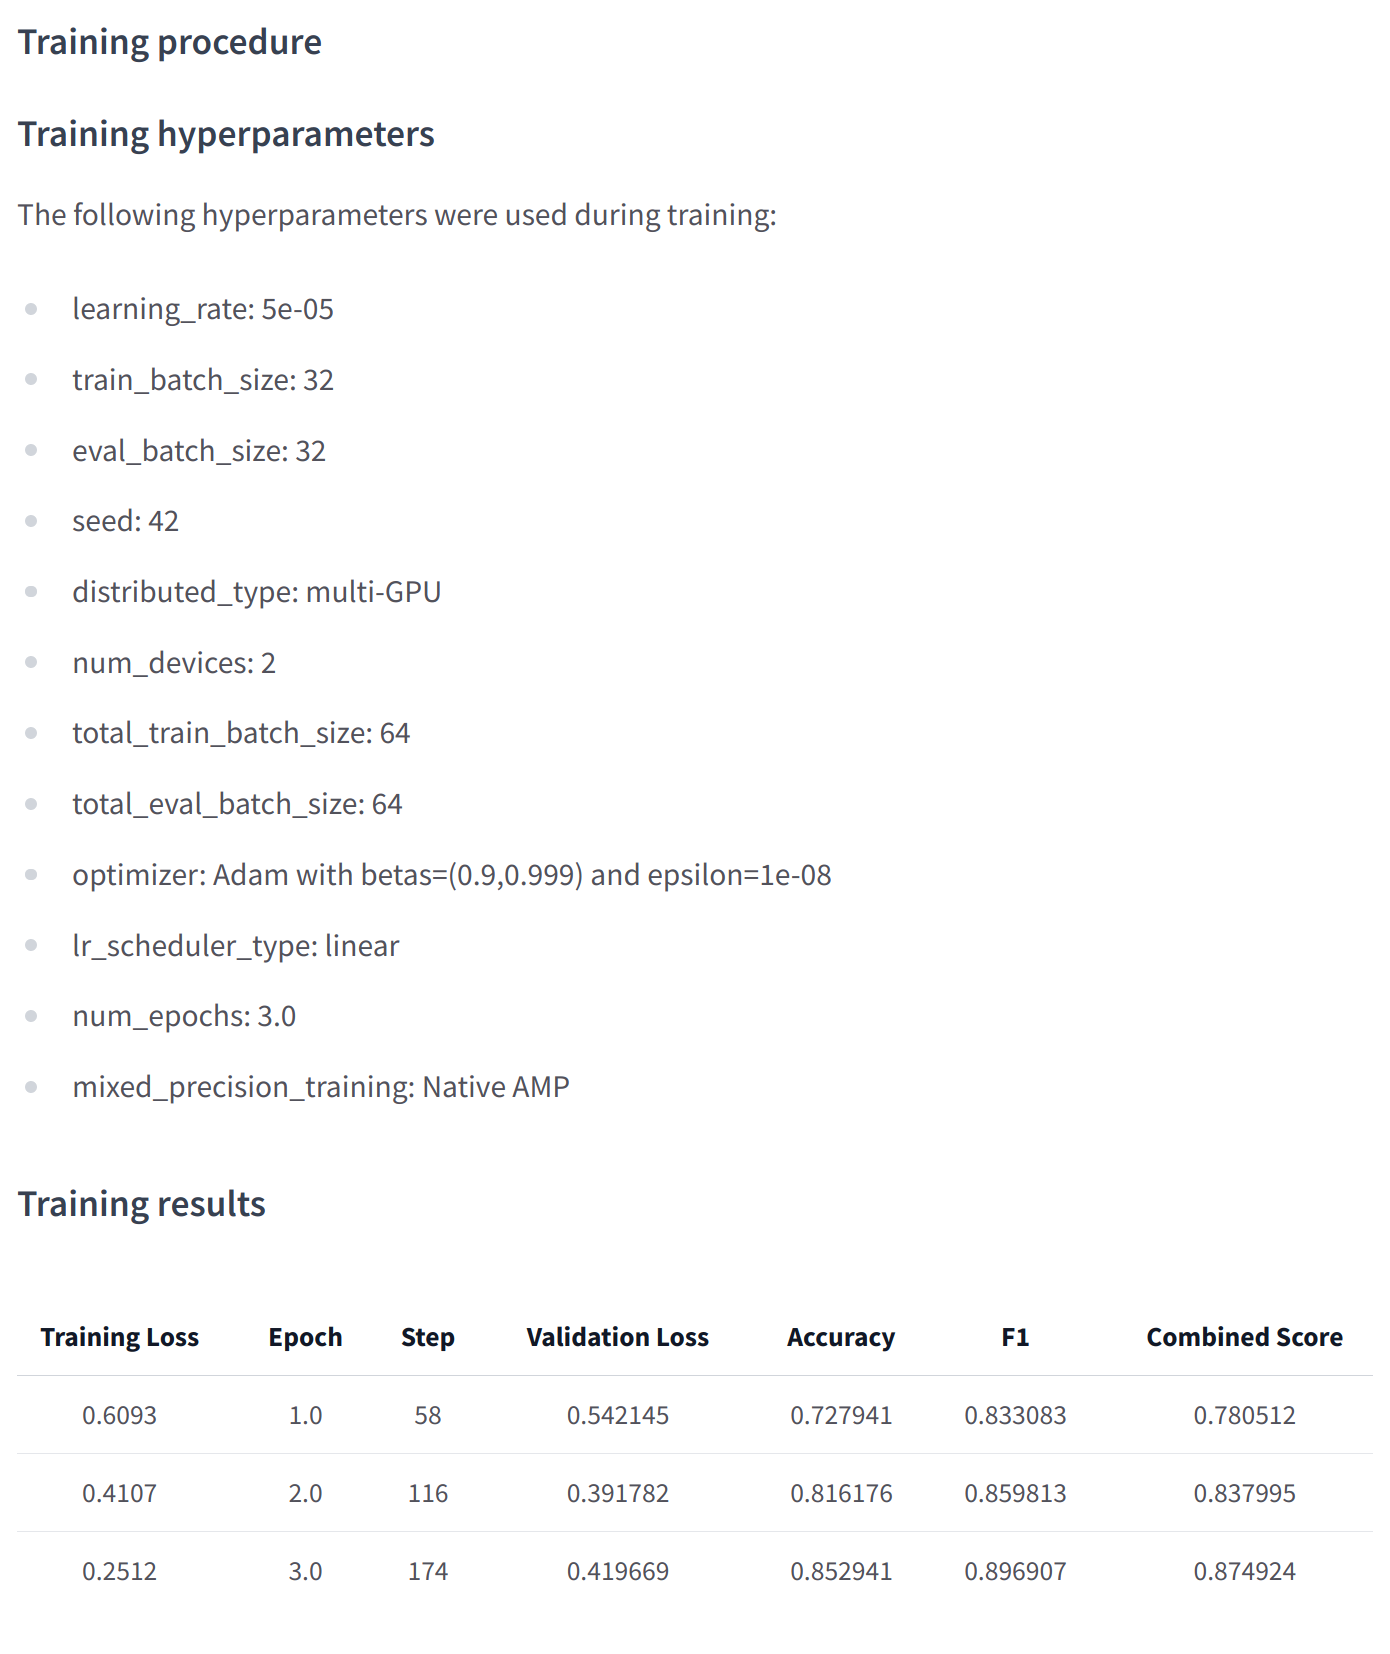

Trainer 可以用来预训练也可以用来微调，但 95% 日常场景大家只用它做微调。

*  pipeline = 推理 / 预测
*  Trainer = 训练 / 微调

###对比三个层级，彻底理清边界
1.  pipeline
*  ✅ 推理（预测）
*  ❌ 不能训练 / 微调
*  黑盒，输入文本直接出结果，看不到 logits、梯度
2. 手动实例化 model + tokenizer
两种用途：

*  自定义推理（拿 logits 自由处理、采样、提取 embedding）
*  手写自定义训练循环（不使用 Trainer）
3. Trainer
*  ✅ 模型训练 / 微调
*  底层依然是 model + tokenizer，但帮你封装全套训练循环。


###更底层的实现方法

在更底层，你可以通过直接**在模型、tokenizer 和配置对象上调用 `push_to_hub()` 方法**来访问模型中心。该方法能够同时创建仓库并直接将模型和 tokenizer 文件推送至仓库，无需手动操作，这与我们在下面要看到的 API 有些许不同。

为了了解它是如何工作的，让我们首先创建一个模型和一个 tokenizer

In [ ]:
from transformers import AutoModelForMaskedLM, AutoTokenizer

checkpoint = "camembert-base"

model = AutoModelForMaskedLM.from_pretrained(checkpoint)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

当你对的模最终的模型、权重和 tokenizer 感到满意，你就可以直接在 model 对象上调用 push_to_hub() 方法：

In [ ]:
model.push_to_hub("dummy-model")

这将在你的账户中创建新的 dummy-model 仓库，并将这个模型文件上传上去。

对 tokenizer 也需要进行相同的操作：

In [ ]:
tokenizer.push_to_hub("dummy-model")

如果你属于一个组织，只需指定 organization 参数即可将模型上传到该组织的账户下：

In [ ]:
tokenizer.push_to_hub("dummy-model", organization="huggingface")

如果你希望使用特定的 Hugging Face 令牌，你也可以很方便地将其传递给 push_to_hub() 方法：

In [ ]:
tokenizer.push_to_hub("dummy-model", organization="huggingface", use_auth_token="<TOKEN>")

##使用 huggingface_hub python 库

huggingface_hub Python 库是一个包，为模型和数据集中心提供了一系列工具。它提供了简单的方法和类，可以便捷地获取 hub 中仓库的信息以及管理仓库等常见任务。它在 git 的基础上提供了简单的 API，可以在你你的项目中管理这些仓库的内容，以及 hub 的一些功能。

与使用 push_to_hub API 类似，这需要你将 API 令牌保存在缓存中。为此，你需要在操作系统的命令行使用 CLI 中的 login 命令，（如果在 Notebook 中运行，请在这些命令前添加 ! 字符）：

In [ ]:
from huggingface_hub import (
    # User management
    login,
    logout,
    whoami,

    # Repository creation and management
    create_repo,
    delete_repo,
    update_repo_visibility,

    # And some methods to retrieve/change information about the content
    list_models,
    list_datasets,
    list_metrics,
    list_repo_files,
    upload_file,
    delete_file,
)

可以使用 create_repo 方法在 Hub 上创建新的仓库：

In [ ]:
from huggingface_hub import create_repo

create_repo("dummy-model")

这将在你的账户中创建 dummy-model 仓库。除此之外你还可以使用 organization 参数指定仓库应属于哪个组织：

In [ ]:
from huggingface_hub import create_repo

create_repo("dummy-model", organization="huggingface")

##使用网络界面

Web 界面提供了直接在 Hub 中管理仓库的工具。使用该界面，你可以轻松创建仓库、添加文件（甚至是大文件！）、探索模型、可视化差异等等。

要创建新的仓库，请访问 huggingface.co/new ：


##上传模型文件

Hugging Face Hub 的文件管理系统基于 git 用于处理常规文件，对于较大的文件则需要使用 git-lfs（详情请参阅 Git 大文件存储 ）

我们会讲述怎么以三种不同的方式将文件上传到 Hub： `upload_file` 方法、 `Repository` 类 以及通过 `git` 命令。

###upload_file 方法

使用 upload_file 不需要在你的系统上安装 git 和 git-lfs。它使用 HTTP POST 请求将文件直接发送到 Hub。这种方法的一个限制是它不能上传大于 5GB 的文件。如果你的文件大于 5GB，请按照另外两种方法进行操作。 upload_file 的使用方法如下：

Copied


In [ ]:
from huggingface_hub import upload_file

upload_file(
    "<path_to_file>/config.json",
    path_in_repo="config.json",
    repo_id="<namespace>/dummy-model",
)

###Repository 类
Repository 类可以使用类似 git 的方式管理一个本地仓库。它解决了使用 git 可能遇到的大部分痛点，提供我们所需的所有功能。

使用这个类需要安装 git 和 git-lfs，所以请确保你已经安装了 git-lfs（如果没有安装，可以查看 git-lfs 官网 的安装指南）并已经在操作系统里配置好了相关功能。

In [ ]:
from huggingface_hub import Repository

repo = Repository("<path_to_dummy_folder>", clone_from="<namespace>/dummy-model")

以上代码会在我们当前的工作目录中创建 <path_to_dummy_folder> 文件夹。此文件夹里只有 .gitattributes 文件，这是使用 create_repo 创建仓库时生成的文件。

从现在开始，我们可以利用许多传统的 git 方法：

In [ ]:
repo.git_pull()
repo.git_add()
repo.git_commit()
repo.git_push()
repo.git_tag()

首先，我们通过拉取最新的更改，确保我们的本地克隆是最新的：

In [ ]:
repo.git_pull()

完成后，我们保存模型和 tokenizer 文件：

In [ ]:
model.save_pretrained("<path_to_dummy_folder>")
tokenizer.save_pretrained("<path_to_dummy_folder>")

<path_to_dummy_folder> 现在已经存储了模型和 tokenizer 文件。我们遵循常规的 git 工作流程，将文件添加到暂存区，提交它们并推送它们到 hub：

In [ ]:
repo.git_add()
repo.git_commit("Add model and tokenizer files")
repo.git_push()

###基于 git 的方法

这是上传文件的最基础方法：我们将直接使用 git 和 git-lfs 进行操作，**相比于之前的方法难度更大同时也更加灵活**。在前面的方法大部分的难点都已经被封装好的库解决，但是接下来的方法需要手动来解决它们，所以我们会尝试一个更复杂的使用案例。



In [ ]:
from transformers import AutoModelForMaskedLM, AutoTokenizer

checkpoint = "camembert-base"

model = AutoModelForMaskedLM.from_pretrained(checkpoint)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# Do whatever with the model, train it, fine-tune it...

model.save_pretrained("<path_to_dummy_folder>")
tokenizer.save_pretrained("<path_to_dummy_folder>")